In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler


    hype-para-1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27     0.577766     0.428772     0.425826     0.249007        -4.025542    file
30     0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31     0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32     0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24     0.326076     0.472367     0.453192     0.105887        -6.702089    file
23     0.282138     0.505987     0.530531     0.096302        -7.966775    file
4      0.124871     0.129770     0.384400     0.287076       -10.069633    file
21     0.170347     0.756959     0.276520     0.531231       -11.565742    file
2      0.250946     0.033693     0.145380     0.494932       -11.699932    file
6      0.247708     0.060445     0.042186     0.441324       -12.681685    file
9      0.626071     0.586751     0.438806     0.778858       -12.741766    file
16     0.216911     0.166086     0.24137

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_85715/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


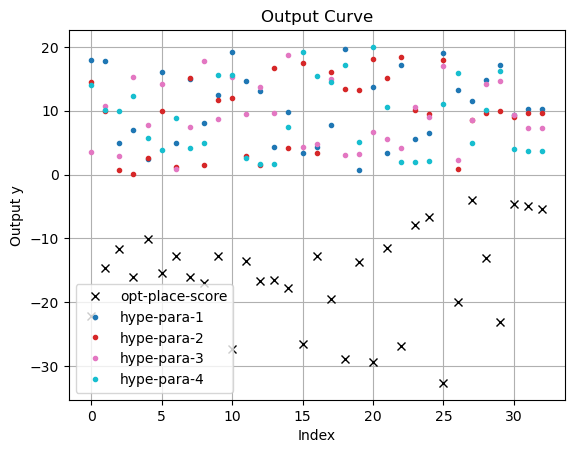

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
X = inputs
y = outputs

In [4]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []

In [5]:
param_grid = [
    {'method': 'PI', 'xi': 0.01},
    {'method': 'PI', 'xi': 0.05},
    {'method': 'PI', 'xi': 0.1},
    {'method': 'UCB', 'kappa': 1.0},
    {'method': 'UCB', 'kappa': 2.0},
    {'method': 'UCB', 'kappa': 3.0},
    {'method': 'EI', 'xi': 0.01},
    {'method': 'EI', 'xi': 0.05},
    {'method': 'EI', 'xi': 0.1},
]

print("Starting acquisition sweep...")

# Shared config
apply_scaling = True
grid_size = 100
dimension = X.shape[1] - 1
filter_mode = 'median'

print("Number of features:", X.shape[1])
y_scaled = preprocess_y(y, apply_scaling)
bounds = compute_bounds(X)
X_grid = create_nd_grid(bounds, grid_size, dimension)
X_grid_filtered = filter_grid(X, y_scaled, X_grid, filter_mode)
gp_model = train_gp(X, y_scaled)

mean, std = gp_model.predict(X_grid_filtered, return_std=True)
print("GP prediction stats:")
print("  Mean shape:", mean.shape)
print("  Std shape :", std.shape)

# --- Parameter sweep ---
for params in param_grid:
    method = params['method']
    xi = params.get('xi', 0.1)
    kappa = params.get('kappa', 2.0)
    label_param = xi if method in ['PI', 'EI'] else kappa

    next_point, acq_vals, _, _ = select_next_query_from_gp(
        X_grid=X_grid_filtered, y=y_scaled, method=method, xi=xi, kappa=kappa,
        mean=mean, std=std  # reuse cached predictions
    )
    score = acq_vals[np.argmax(acq_vals)]
    print(f"[{method} | {label_param}] → Next query point: {next_point}, Score: {score:.4f}")
    log_query_candidate(method, label_param, next_point, score)

Starting acquisition sweep...
Number of features: 4
Applying standard scaling to y.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.062175171466653995, 1.0856218929694017), (-0.09374959975508215, 1.0195923219593923), (-0.05781365486280224, 1.0391779073552307), (-0.01848343580966985, 1.0994825612275692)]
Creating 100^(4) grid.
Grid shape: (100000000, 4)
Filtering grid using mode: median
Filtered 15389340 candidates near decision boundary (|margin| < 0.2)
Excluded 84610660 candidates from consideration
Final grid shape: (15389340, 4)
Filtered grid shape: (15389340, 4)
Using default RBF kernel.
GP model trained.
GP prediction stats:
  Mean shape: (15389340,)
  Std shape : (15389340,)
Using cached GP predictions.
Computing acquisition for method: PI
[PI | 0.01] → Next query point: [0.11173347 0.04120094 0.54054538 0.28641638], Score: 0.0694
Using cached GP predictions.
Computing acquisition for method: PI
[PI | 0.05] → Next query point: [0.11173347 0.04120094 0.54054538 0.286416

In [6]:
find_best_candidate(query_results)

Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]), 'score': 0.0694451489806951, 'dim': 4}
{'method': 'PI', 'xi': 0.05, 'kappa': None, 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]), 'score': 0.06416213693842465, 'dim': 4}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]), 'score': 0.058004011291795325, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.20448475, 0.86215003, 0.3078502 , 0.54614586]), 'score': 1.166739870354126, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]), 'score': 2.118564973522558, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]), 'score': 3.0987849323389978, 'dim': 4}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.11173347, 0.04120094, 0.54054538, 

{'method': 'UCB',
 'xi': None,
 'kappa': 3.0,
 'x': array([0.11173347, 0.04120094, 0.54054538, 0.28641638]),
 'score': 3.0987849323389978,
 'dim': 4}

In [7]:
#add points to dataframe
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27     0.577766     0.428772     0.425826     0.249007        -4.025542    file
30     0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31     0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32     0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24     0.326076     0.472367     0.453192     0.105887        -6.702089    file
23     0.282138     0.505987     0.530531     0.096302        -7.966775    file
4      0.124871     0.129770     0.384400     0.287076       -10.069633    file
21     0.170347     0.756959     0.276520     0.531231       -11.565742    file
2      0.250946     0.033693     0.145380     0.494932       -11.699932    file
6      0.247708     0.060445     0.042186     0.441324       -12.681685    file
9      0.626071     0.586751     0.438806     0.778858       -12.741766    file
16     0.216911     0.166086     0.24137

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_85715/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


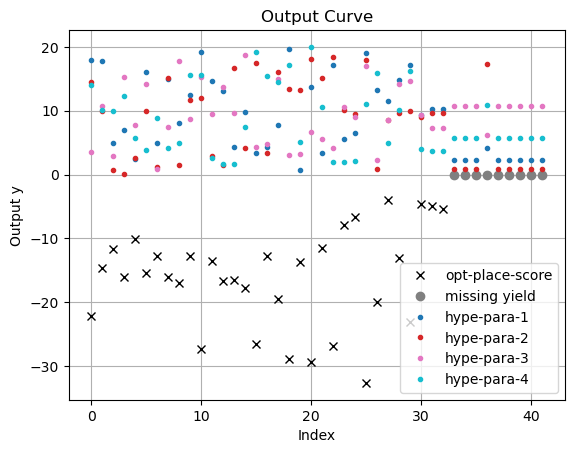

In [8]:
plot_output_points(df_sorted, scale_factor=20.0, yield_scale_factor=1.0)